In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

In [2]:
data=pd.read_csv('QualityPrediction.csv')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [4]:
np.shape(data)

(1599, 12)

In [5]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


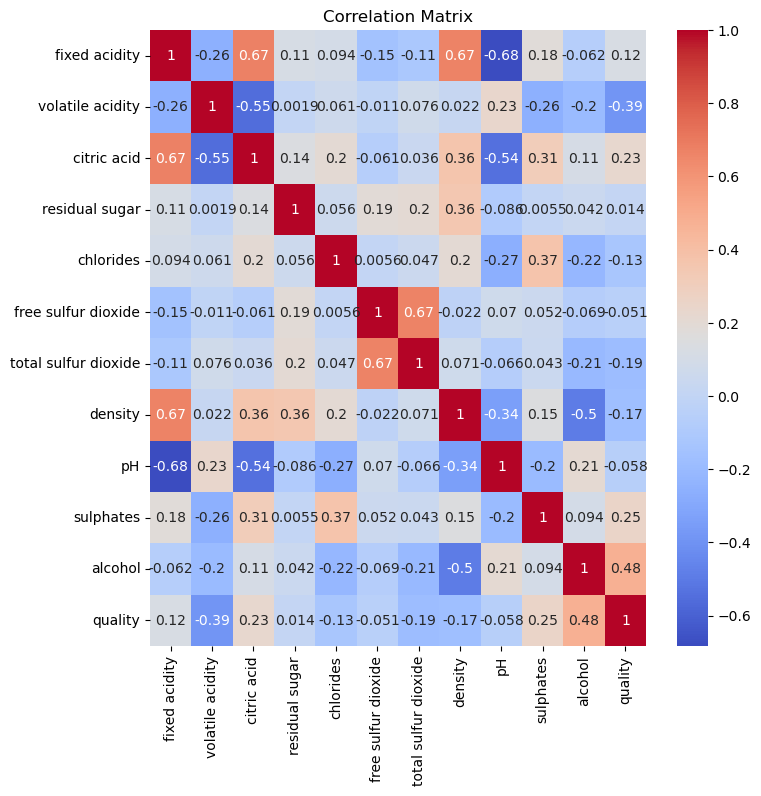

In [7]:
#Correlation 

corr_matrix = data.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [8]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [9]:
for column in data.columns[:-1]:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = (data[column] < (Q1 - 1.5 * IQR)) | (data[column] > (Q3 + 1.5 * IQR))
    df_outliers = data[column][outliers]
    print (f"total number of outliers for {column} :{len (df_outliers)}")
    print(f"percentage of Outliers for {column} based on IQR: {round(len(df_outliers)/len(data[column])*100)}% ")
    print("***"*20)
    

total number of outliers for fixed acidity :49
percentage of Outliers for fixed acidity based on IQR: 3% 
************************************************************
total number of outliers for volatile acidity :19
percentage of Outliers for volatile acidity based on IQR: 1% 
************************************************************
total number of outliers for citric acid :1
percentage of Outliers for citric acid based on IQR: 0% 
************************************************************
total number of outliers for residual sugar :155
percentage of Outliers for residual sugar based on IQR: 10% 
************************************************************
total number of outliers for chlorides :112
percentage of Outliers for chlorides based on IQR: 7% 
************************************************************
total number of outliers for free sulfur dioxide :30
percentage of Outliers for free sulfur dioxide based on IQR: 2% 
*************************************************

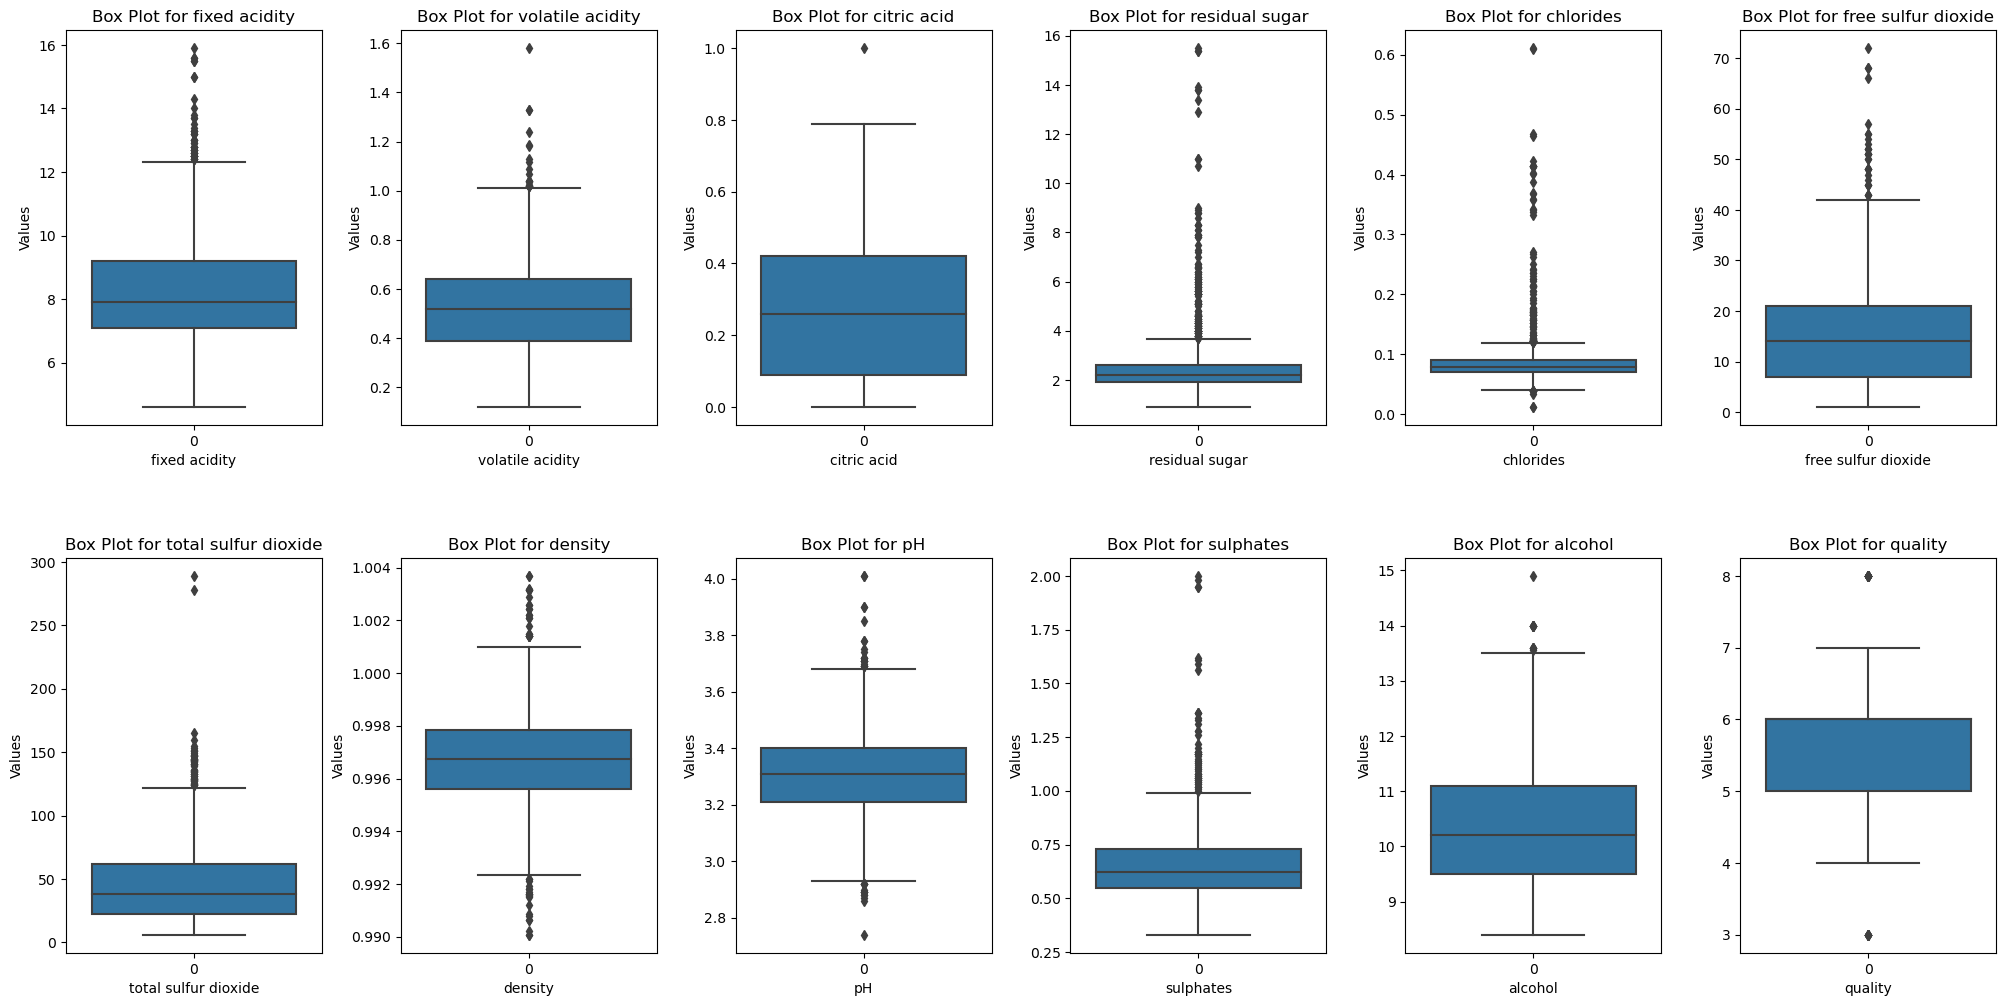

In [10]:
fig,ax=plt.subplots(ncols=6,nrows=2,figsize=(20,10))
index=0
ax=ax.flatten()
                    
for index, column in enumerate(data.columns):
    sns.boxplot(data=data[column], ax=ax[index])
    ax[index].set_title(f'Box Plot for {column}')
    ax[index].set_xlabel(f'{column}')
    ax[index].set_ylabel('Values')   
# Display the plot
plt.tight_layout(pad=0.5,w_pad=0.7, h_pad= 5.0)
plt.show()

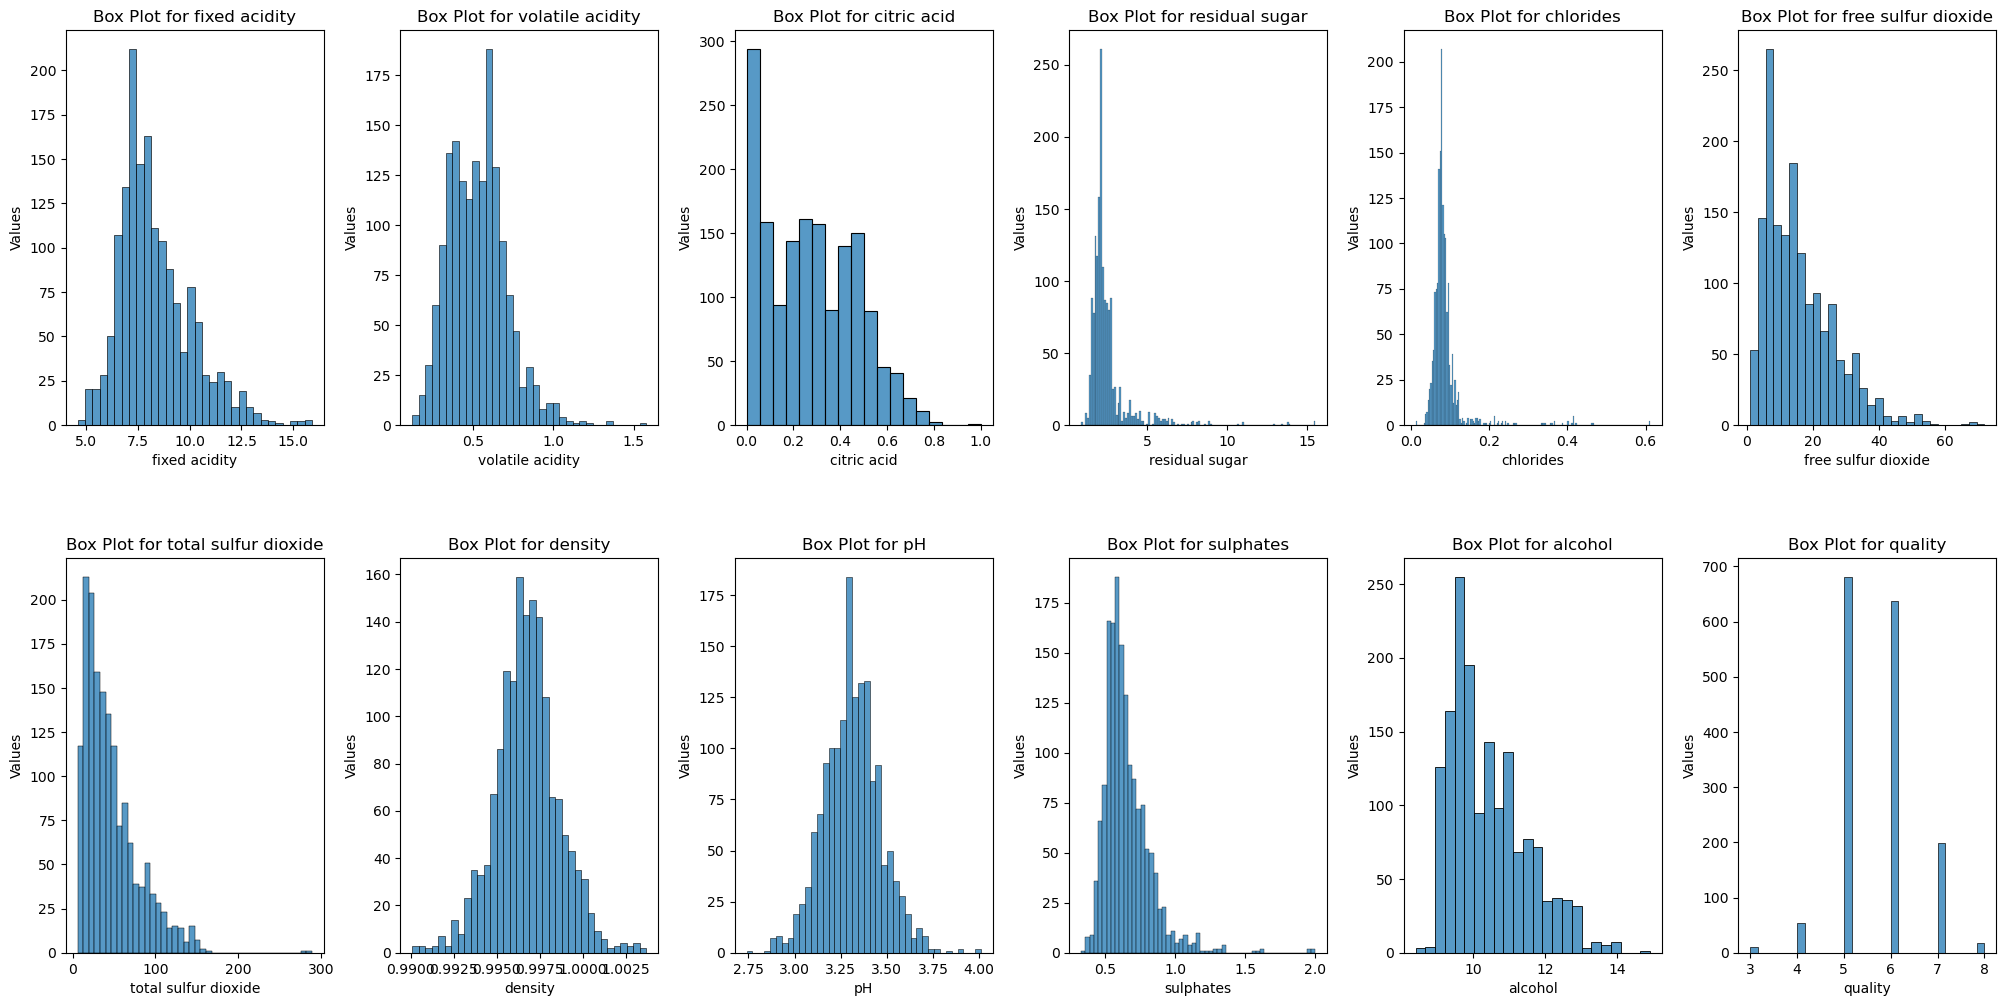

In [11]:
fig,ax=plt.subplots(ncols=6,nrows=2,figsize=(20,10))
index=0
ax=ax.flatten()
                    
for index, column in enumerate(data.columns):
    sns.histplot(data=data[column], ax=ax[index])
    ax[index].set_title(f'Box Plot for {column}')
    ax[index].set_xlabel(f'{column}')
    ax[index].set_ylabel('Values')   
# Display the plot
plt.tight_layout(pad=0.5,w_pad=0.7, h_pad= 5.0)
plt.show()

In [12]:
# treating the columns residual sugar and chlorides because they have the most outliers,
# treatment done is log 
data['residual sugar'] = np.log(data['residual sugar'] + 1) 
data["chlorides"]= np.log(data['chlorides'] + 1) 

In [13]:
# outlier treatment capping
#for column in data.columns[:-1]:
    #lower_bound = Q1 - 1.5 * IQR
    #upper_bound = Q3 + 1.5 * IQR
    #data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
    #data[column] = np.where(data[column] > upper_bound, upper_bound,data[column])

In [14]:
data.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.064711,0.073250,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,1.280934,0.093490,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,1.193922,0.088011,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.064711,0.072321,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.064711,0.073250,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [15]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,1.218131,0.083038,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,0.269969,0.038991,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.641854,0.011929,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.064711,0.067659,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,1.163151,0.076035,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,1.280934,0.086178,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,2.803360,0.476855,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


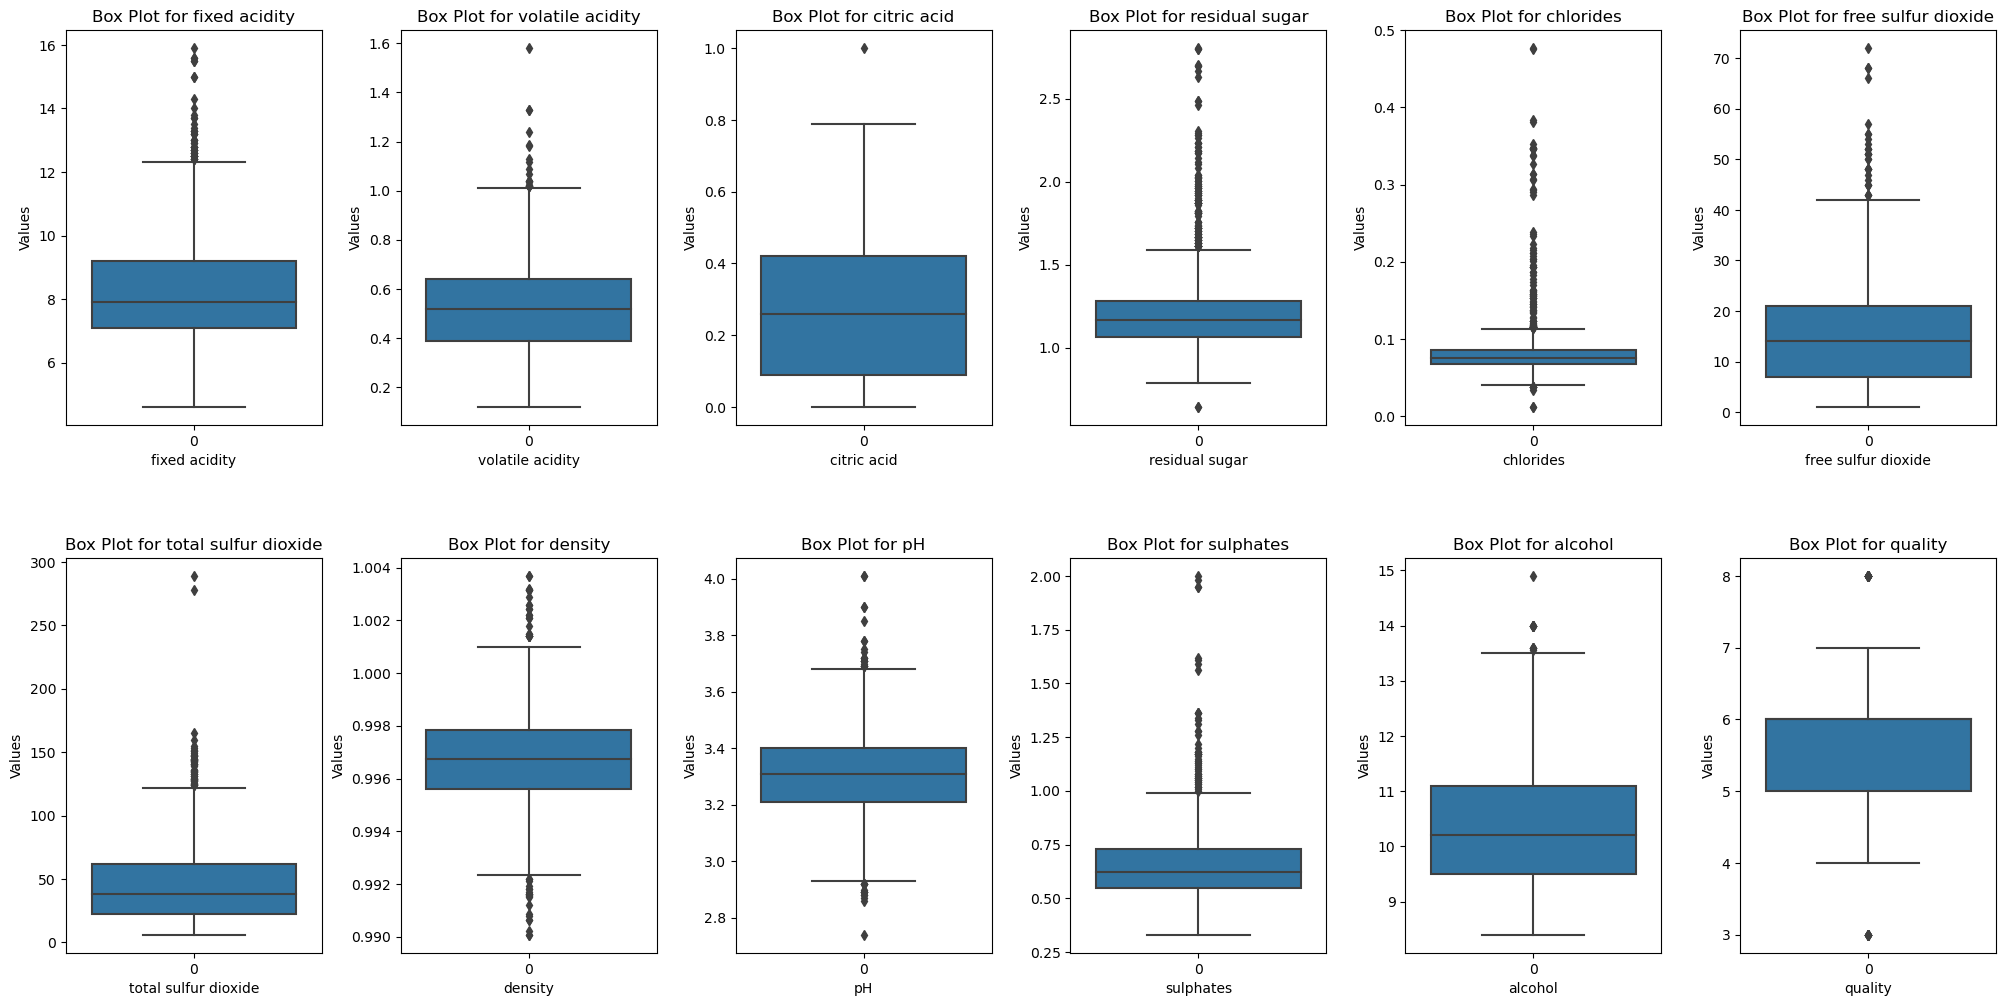

In [16]:
fig,ax=plt.subplots(ncols=6,nrows=2,figsize=(20,10))
index=0
ax=ax.flatten()
                    
for index, column in enumerate(data.columns):
    sns.boxplot(data=data[column], ax=ax[index])
    ax[index].set_title(f'Box Plot for {column}')
    ax[index].set_xlabel(f'{column}')
    ax[index].set_ylabel('Values')   
# Display the plot
plt.tight_layout(pad=0.5,w_pad=0.7, h_pad= 5.0)
plt.show()

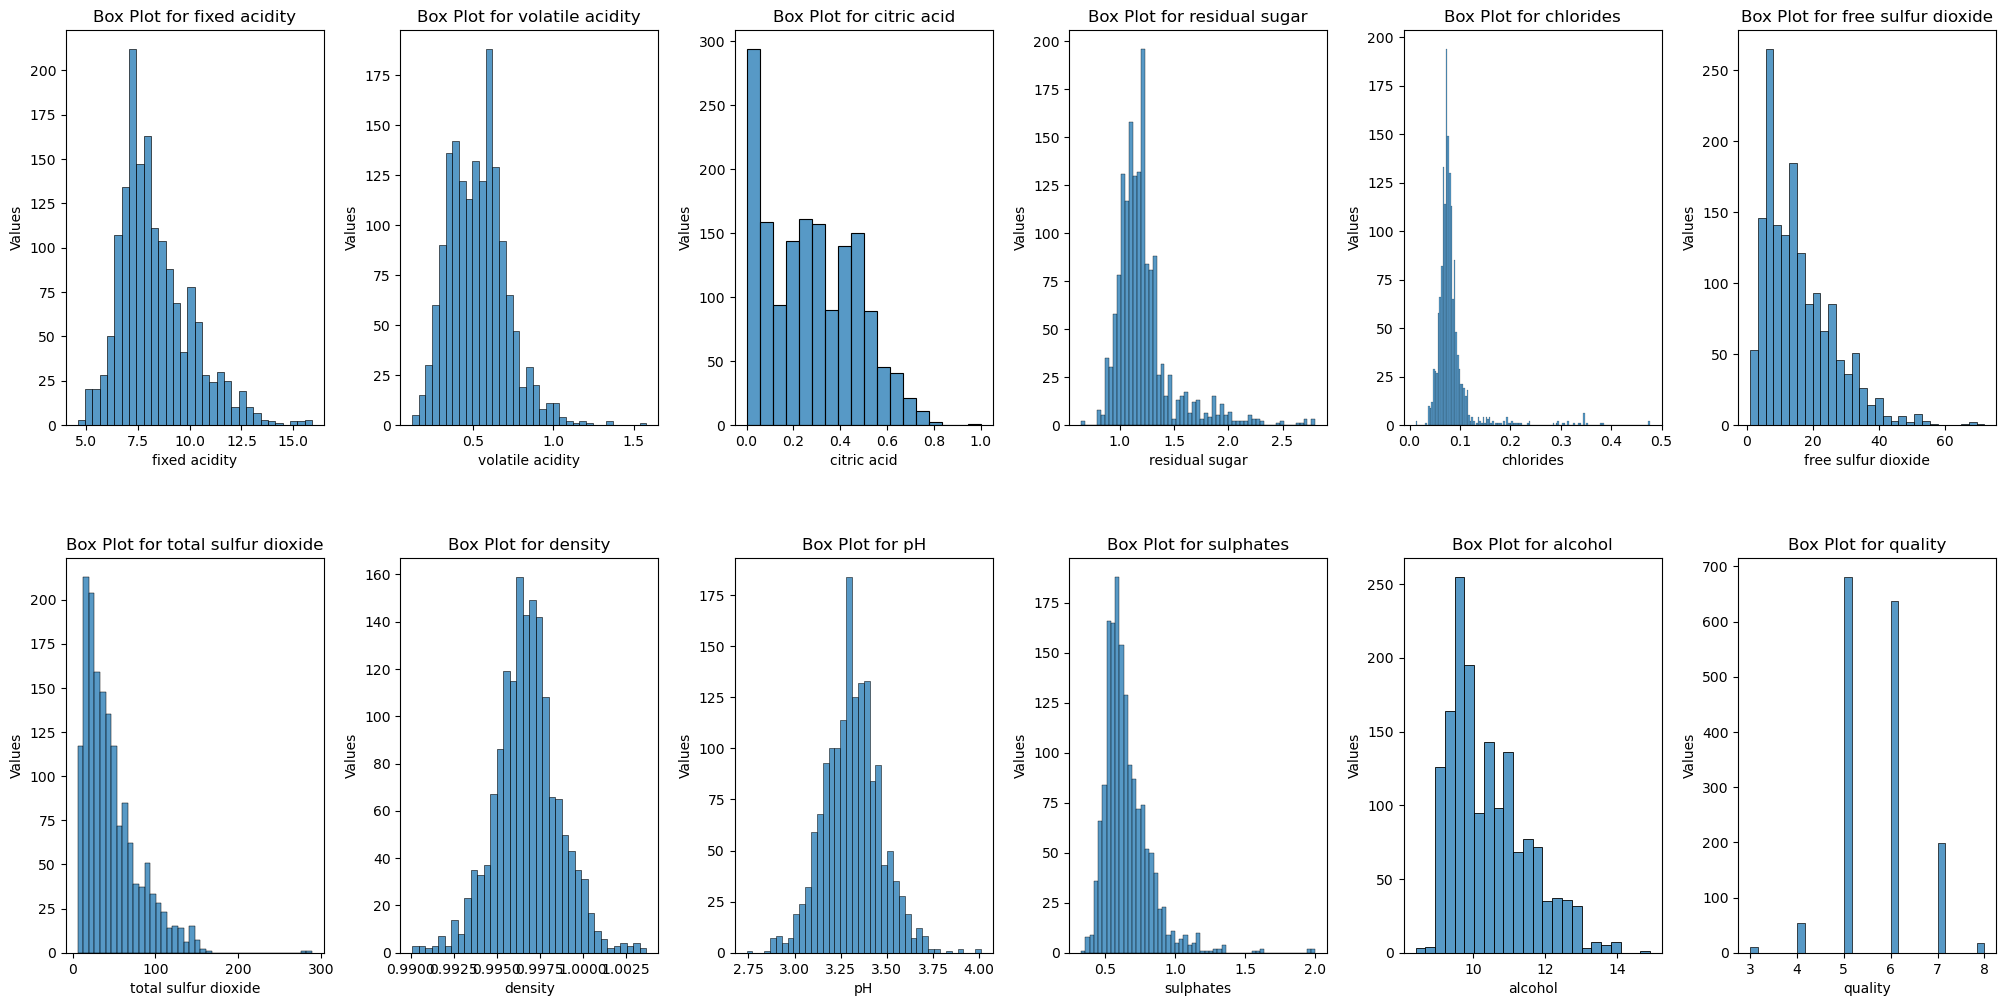

In [17]:

fig,ax=plt.subplots(ncols=6,nrows=2,figsize=(20,10))
index=0
ax=ax.flatten()
                    
for index, column in enumerate(data.columns):
    sns.histplot(data=data[column], ax=ax[index])
    ax[index].set_title(f'Box Plot for {column}')
    ax[index].set_xlabel(f'{column}')
    ax[index].set_ylabel('Values')   
# Display the plot
plt.tight_layout(pad=0.5,w_pad=0.7, h_pad= 5.0)
plt.show()


In [18]:
data.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.064711,0.073250,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,1.280934,0.093490,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,1.193922,0.088011,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.064711,0.072321,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.064711,0.073250,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [19]:
# copying the data so as to not hinder the original data
import copy
data_copy=copy.deepcopy(data)
data_copy.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.064711,0.073250,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,1.280934,0.093490,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,1.193922,0.088011,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.064711,0.072321,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.064711,0.073250,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [20]:
data_copy.isnull().sum()
    

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [21]:
data_copy.nunique()

fixed acidity            96
volatile acidity        143
citric acid              80
residual sugar           91
chlorides               153
free sulfur dioxide      60
total sulfur dioxide    144
density                 436
pH                       89
sulphates                96
alcohol                  65
quality                   6
dtype: int64

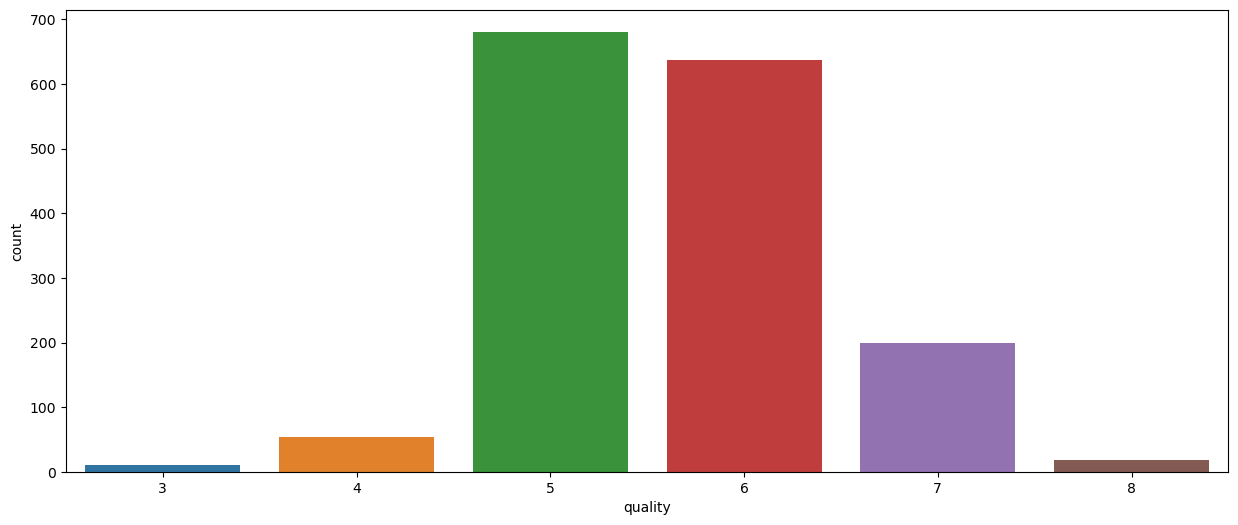

In [22]:
plt.figure(figsize=(15,6)) # plotting it into a graph for predicted column
sns.countplot(x='quality',data=data)
plt.show()

In [23]:
G_B= []
for quality in data_copy['quality']:
    if quality>=1 and quality <=7:
        G_B.append(0)
        
    else:
        G_B.append(1)

In [24]:
print(G_B[0:10])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [25]:
data_copy['G_B']=G_B
data_copy.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,G_B
0,7.4,0.70,0.00,1.064711,0.073250,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,1.280934,0.093490,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,1.193922,0.088011,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.064711,0.072321,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.064711,0.073250,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
5,7.4,0.66,0.00,1.029619,0.072321,13.0,40.0,0.9978,3.51,0.56,9.4,5,0
6,7.9,0.60,0.06,0.955511,0.066724,15.0,59.0,0.9964,3.30,0.46,9.4,5,0
7,7.3,0.65,0.00,0.788457,0.062975,15.0,21.0,0.9946,3.39,0.47,10.0,7,0
8,7.8,0.58,0.02,1.098612,0.070458,9.0,18.0,0.9968,3.36,0.57,9.5,7,0
9,7.5,0.50,0.36,1.960095,0.068593,17.0,102.0,0.9978,3.35,0.80,10.5,5,0


In [26]:
#Split the data into independent and dep variables
drop_colums=['quality','G_B']
X = data_copy.drop(columns=drop_colums, axis = 1)
y = data_copy['G_B']

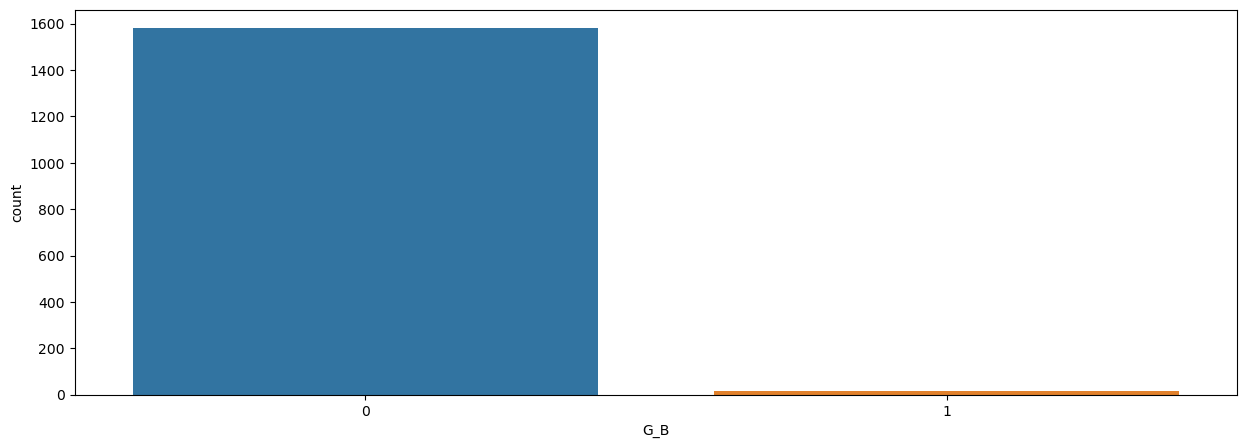

In [27]:
plt.figure(figsize=(15,5)) # plotting it into a graph for predicted column
sns.countplot(x='G_B',data=data_copy)
plt.show()

In [28]:
y.value_counts()

G_B
0    1581
1      18
Name: count, dtype: int64

In [29]:
#Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 35)

In [30]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
y_train.value_counts()

G_B
0    1267
1      12
Name: count, dtype: int64

In [32]:
# Balancing the y train
from imblearn.combine import SMOTETomek

In [33]:
smt = SMOTETomek(random_state = 101, sampling_strategy = 'minority')
X_res, y_res = smt.fit_resample(X_train_scaled, y_train)

In [34]:
print ("before applying smotetomek=  ", y_train.value_counts())
print ("before applying smotetomek=  ", y_res.value_counts())

before applying smotetomek=   G_B
0    1267
1      12
Name: count, dtype: int64
before applying smotetomek=   G_B
0    1267
1    1267
Name: count, dtype: int64


# using logistic regression¶

In [35]:
# applying the model

model_lr = LogisticRegression(max_iter = 1000)
model_lr.fit(X_res, y_res)

LogisticRegression(max_iter=1000)

In [36]:
#Training Evaluation
y_train_pred_lr = model_lr.predict(X_res)

training_accuracy_lr = accuracy_score(y_res, y_train_pred_lr)
print("Training Accuracy ", training_accuracy_lr)

#Test Evaluation
y_test_pred_lr = model_lr.predict(X_test_scaled)

test_accuracy_lr = accuracy_score(y_test, y_test_pred_lr)
print("Test Accuracy ", test_accuracy_lr)

#Confusion Matrix
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
print (f"confussion matrix={cm_lr} " )

Training Accuracy  0.9372533543804262
Test Accuracy  0.821875
confussion matrix=[[258  56]
 [  1   5]] 


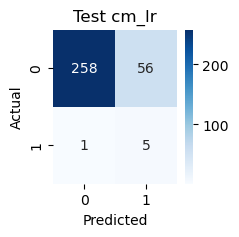

In [37]:
plt.figure(figsize=(2,2))
sns.heatmap(cm_lr, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test cm_lr')
plt.show()

## using knn algorithm


In [38]:
from sklearn.neighbors import KNeighborsClassifier
model_knn=KNeighborsClassifier(n_neighbors=3)
model_knn.fit(X_res, y_res)

KNeighborsClassifier(n_neighbors=3)

In [39]:
#Training Evaluation
y_train_pred_knn = model_knn.predict(X_res)

training_accuracy_knn = accuracy_score(y_res, y_train_pred_knn)
print("Training Accuracy ", training_accuracy_knn)

#Test Evaluation
y_test_pred_knn = model_knn.predict(X_test_scaled)

test_accuracy_knn = accuracy_score(y_test, y_test_pred_knn)
print("Test Accuracy ", test_accuracy_knn)

#Confusion Matrix
cm_knn = confusion_matrix(y_test, y_test_pred_knn)
print (f"confussion matrix={cm_knn} " )

Training Accuracy  0.9850039463299132
Test Accuracy  0.890625
confussion matrix=[[284  30]
 [  5   1]] 


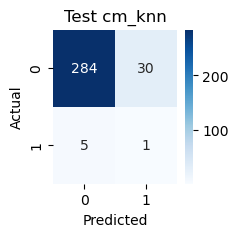

In [40]:
plt.figure(figsize=(2,2))
sns.heatmap(cm_knn, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test cm_knn')
plt.show()

## using dessision tree

In [41]:
from sklearn.tree import DecisionTreeClassifier
model_dt= DecisionTreeClassifier(criterion="entropy",random_state=7)
model_dt.fit(X_res, y_res)

DecisionTreeClassifier(criterion='entropy', random_state=7)

In [42]:
#Training Evaluation
y_train_pred_dt = model_dt.predict(X_res)

training_accuracy_dt = accuracy_score(y_res, y_train_pred_dt)
print("Training Accuracy ", training_accuracy_dt)

#Test Evaluation
y_test_pred_dt = model_dt.predict(X_test_scaled)

test_accuracy_dt = accuracy_score(y_test, y_test_pred_dt)
print("Test Accuracy ", test_accuracy_dt)

#Confusion Matrix
cm_dt = confusion_matrix(y_test, y_test_pred_dt)
print (f"confussion matrix={cm_dt} " )

Training Accuracy  1.0
Test Accuracy  0.946875
confussion matrix=[[301  13]
 [  4   2]] 


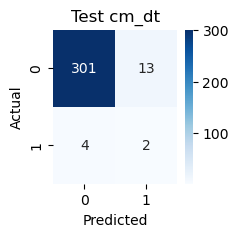

In [43]:
plt.figure(figsize=(2,2))
sns.heatmap(cm_dt, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test cm_dt')
plt.show()

## using Random forest

In [44]:
from sklearn.ensemble import RandomForestClassifier
model_rf=RandomForestClassifier(random_state=1)
model_rf.fit(X_res, y_res)

RandomForestClassifier(random_state=1)

In [45]:
#Training Evaluation
y_train_pred_rf = model_rf.predict(X_res)

training_accuracy_rf = accuracy_score(y_res, y_train_pred_rf)
print("Training Accuracy ", training_accuracy_rf)

#Test Evaluation
y_test_pred_rf = model_rf.predict(X_test_scaled)

test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
print("Test Accuracy ", test_accuracy_rf)

#Confusion Matrix
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
print (f"confussion matrix={cm_rf} " )

Training Accuracy  1.0
Test Accuracy  0.965625
confussion matrix=[[308   6]
 [  5   1]] 


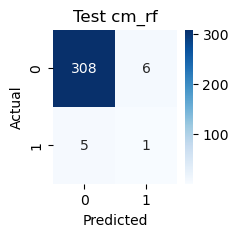

In [46]:
plt.figure(figsize=(2,2))
sns.heatmap(cm_rf, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test cm_rf')
plt.show()

## using XGboost

In [47]:
import xgboost as xgb
model_xgb=xgb.XGBClassifier(random_state=1)
model_xgb.fit(X_res, y_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=1, ...)

In [48]:
#Training Evaluation
y_train_pred_xgb = model_xgb.predict(X_res)

training_accuracy_xgb = accuracy_score(y_res, y_train_pred_xgb)
print("Training Accuracy ", training_accuracy_xgb)


#Test Evaluation
y_test_pred_xgb = model_xgb.predict(X_test_scaled)

test_accuracy_xgb = accuracy_score(y_test, y_test_pred_xgb)
print("Test Accuracy ", test_accuracy_xgb)


#Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)
print (f"confussion matrix={cm_xgb} " )

Training Accuracy  1.0
Test Accuracy  0.959375
confussion matrix=[[305   9]
 [  4   2]] 


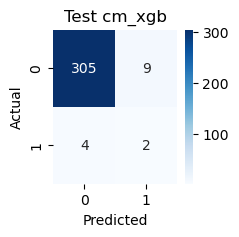

In [49]:
plt.figure(figsize=(2,2))
sns.heatmap(cm_xgb, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test cm_xgb')
plt.show()

In [50]:
from tabulate import tabulate

# Data
table_1 = [
    ["Logistic Regression", test_accuracy_lr],
    ["K-Nearest Neighbors (KNN)", test_accuracy_knn],
    ["Decision Tree", test_accuracy_dt],
    ["Random Forest", test_accuracy_rf],
    ["XGBoost", test_accuracy_xgb]
]

# Print the table
print(tabulate(table_1, headers=["Algorithm", "Test Accuracy"], tablefmt="grid"))

+---------------------------+-----------------+
| Algorithm                 |   Test Accuracy |
+===========================+=================+
| Logistic Regression       |        0.821875 |
+---------------------------+-----------------+
| K-Nearest Neighbors (KNN) |        0.890625 |
+---------------------------+-----------------+
| Decision Tree             |        0.946875 |
+---------------------------+-----------------+
| Random Forest             |        0.965625 |
+---------------------------+-----------------+
| XGBoost                   |        0.959375 |
+---------------------------+-----------------+


In [51]:
# Logistic Regression:
tn_lr, fp_lr, fn_lr, tp_lr = confusion_matrix(y_test, y_test_pred_lr).ravel()
print(f"tn={tn_lr},fp= {fp_lr},fn={fn_lr},tp= {tp_lr}")
#Recall
recall_lr = tp_lr/(tp_lr+fn_lr)
print("Recall of Logistic regression model = ", recall_lr)
#precission
precision_lr = tp_lr/(tp_lr+fp_lr)
print("precession of logistic regression model =", precision_lr)
# f1-score
f1_score_lr = (2 * (precision_lr * recall_lr)) / (precision_lr + recall_lr)
print (f"f1 score of logistic regresssion model ={f1_score_lr}")

tn=258,fp= 56,fn=1,tp= 5
Recall of Logistic regression model =  0.8333333333333334
precession of logistic regression model = 0.08196721311475409
f1 score of logistic regresssion model =0.14925373134328357


In [52]:
# knn model:
tn_knn, fp_knn, fn_knn, tp_knn = confusion_matrix(y_test, y_test_pred_knn).ravel()
print(f"tn={tn_knn},fp= {fp_knn},fn={fn_knn},tp= {tp_knn}")
#Recall
recall_knn = tp_knn/(tp_knn+fn_knn)
print("Recall of knn model = ", recall_knn)
#precission
precision_knn = tp_knn/(tp_knn+fp_knn)
print("precession of knn model =", precision_knn)
# f1-score
f1_score_knn = (2 * (precision_knn * recall_knn)) / (precision_knn + recall_knn)
print (f"f1 score of knn model ={f1_score_knn}")

tn=284,fp= 30,fn=5,tp= 1
Recall of knn model =  0.16666666666666666
precession of knn model = 0.03225806451612903
f1 score of knn model =0.05405405405405405


In [53]:
# decission tree:
tn_dt, fp_dt, fn_dt, tp_dt = confusion_matrix(y_test, y_test_pred_dt).ravel()
print(f"tn={tn_dt},fp= {fp_dt},fn={fn_dt},tp= {tp_dt}")
#Recall
recall_dt = tp_dt/(tp_dt+fn_dt)
print("Recall of decission tree model= ", recall_dt)
#precission
precision_dt = tp_dt/(tp_dt+fp_dt)
print("precession of decission tree model =", precision_dt)
# f1-score
f1_score_dt = (2 * (precision_dt * recall_dt)) / (precision_dt + recall_dt)
print (f"f1 score of dession tree model ={f1_score_dt}")


tn=301,fp= 13,fn=4,tp= 2
Recall of decission tree model=  0.3333333333333333
precession of decission tree model = 0.13333333333333333
f1 score of dession tree model =0.19047619047619044


In [54]:
# random forest:
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(y_test, y_test_pred_rf).ravel()
print(f"tn={tn_rf},fp= {fp_rf},fn={fn_rf},tp= {tp_rf}")
#Recall
recall_rf = tp_rf/(tp_rf+fn_rf)
print("Recall of random forest model = ", recall_rf)
#precission
precision_rf = tp_rf/(tp_rf+fp_rf)
print("precession of random forest model =", precision_rf)
# f1-score
f1_score_rf = (2 * (precision_rf * recall_rf)) / (precision_rf + recall_rf)
print (f"f1 score of random forest model ={f1_score_rf}")


tn=308,fp= 6,fn=5,tp= 1
Recall of random forest model =  0.16666666666666666
precession of random forest model = 0.14285714285714285
f1 score of random forest model =0.15384615384615383


In [55]:
# XGBoost model:
tn_xgb, fp_xgb, fn_xgb, tp_xgb = confusion_matrix(y_test, y_test_pred_xgb).ravel()
print(f"tn={tn_xgb},fp= {fp_xgb},fn={fn_xgb},tp= {tp_xgb}")
#Recall
recall_xgb = tp_xgb/(tp_xgb+fn_xgb)
print("Recall of logisitic regression = ", recall_xgb)
#precission
precision_xgb = tp_xgb/(tp_xgb+fp_xgb)
print("precession of logistic regression =", precision_xgb)
# f1-score
f1_score_xgb = (2 * (precision_xgb * recall_xgb)) / (precision_xgb + recall_xgb)
print (f"f1 score of logistic regression ={f1_score_xgb}")


tn=305,fp= 9,fn=4,tp= 2
Recall of logisitic regression =  0.3333333333333333
precession of logistic regression = 0.18181818181818182
f1 score of logistic regression =0.23529411764705885


In [58]:
table_2 = [
    ["Logistic Regression Model", test_accuracy_lr,tn_lr, fp_lr, fn_lr, tp_lr,recall_lr,precision_lr,f1_score_lr],
    ["K-Nearest Neighbors (KNN) Model", test_accuracy_knn,tn_knn, fp_knn, fn_knn, tp_knn,recall_knn,precision_knn,f1_score_knn],
    ["Decision Tree Model", test_accuracy_dt,tn_dt, fp_dt, fn_dt, tp_dt,recall_dt,precision_dt,f1_score_dt],
    ["Random Forest Model", test_accuracy_rf,tn_rf, fp_rf, fn_rf, tp_rf,recall_rf,precision_rf,f1_score_rf],
    ["XGBoost Model", test_accuracy_xgb,tn_xgb, fp_xgb, fn_xgb, tp_xgb,recall_xgb,precision_xgb,f1_score_xgb]
]

# Print the table
print(tabulate(table_2, headers=["Algorithm","Test Acc","TN","FP","FN","TP","Recall","Precission","F1score"], tablefmt="grid"))


+---------------------------------+------------+------+------+------+------+----------+--------------+-----------+
| Algorithm                       |   Test Acc |   TN |   FP |   FN |   TP |   Recall |   Precission |   F1score |
+=================================+============+======+======+======+======+==========+==============+===========+
| Logistic Regression Model       |   0.821875 |  258 |   56 |    1 |    5 | 0.833333 |    0.0819672 | 0.149254  |
+---------------------------------+------------+------+------+------+------+----------+--------------+-----------+
| K-Nearest Neighbors (KNN) Model |   0.890625 |  284 |   30 |    5 |    1 | 0.166667 |    0.0322581 | 0.0540541 |
+---------------------------------+------------+------+------+------+------+----------+--------------+-----------+
| Decision Tree Model             |   0.946875 |  301 |   13 |    4 |    2 | 0.333333 |    0.133333  | 0.190476  |
+---------------------------------+------------+------+------+------+------+----